In [1]:
# ============================================================
# A4 · Cellule 0 — Configuration
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
import networkx as nx
import unicodedata
from pathlib import Path
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

BASE    = Path('.')
DATA_A4 = BASE / 'data'
DATA    = Path('..') / 'data'
A3_OUT  = Path('..') / 'A3_sentiment' / 'outputs'
OUT     = BASE / 'outputs'
OUT.mkdir(exist_ok=True)

# ── Palettes candidats ──────────────────────────────────────────────────────
COLORS = {
    'Brossat':  '#E63946', 'Chikirou': '#FF6B6B', 'Belliard': '#2A9D8F',
    'Gregoire': '#E9C46A', 'Bournazel':'#F4A261', 'Dati':     '#457B9D',
    'Knafo':    '#6D4C41', 'Mariani':  '#264653'
}
SHORT = {
    'Brossat':'Brossat (PCF)',         'Chikirou':'Chikirou (LFI)',
    'Belliard':'Belliard (EELV)',      'Gregoire':'Gregoire (PS)',
    'Bournazel':'Bournazel (Horizons)','Dati':'Dati (LR)',
    'Knafo':'Knafo (Reconquete)',      'Mariani':'Mariani (RN)'
}
ID_TO_KEY = {
    'ian_brossat':'Brossat',               'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',           'emmanuel_gregoire':'Gregoire',
    'pierre_yves_bournazel':'Bournazel',   'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',                 'thierry_mariani':'Mariani'
}

# ── Position ideologique (echelle gauche=1 → droite=8) ─────────────────────
IDEO = {
    'Brossat':1, 'Chikirou':2, 'Belliard':3, 'Gregoire':4,
    'Bournazel':5, 'Dati':6, 'Knafo':7, 'Mariani':8
}
CAMP = {
    'Brossat':'Extreme gauche', 'Chikirou':'Extreme gauche',
    'Belliard':'Gauche',        'Gregoire':'Gauche',
    'Bournazel':'Centre',       'Dati':'Droite',
    'Knafo':'Extreme droite',   'Mariani':'Extreme droite'
}
CAMP_COLOR = {
    'Extreme gauche':'#E63946', 'Gauche':'#2A9D8F',
    'Centre':'#F4A261',         'Droite':'#457B9D',
    'Extreme droite':'#264653'
}

# ── Style matplotlib ────────────────────────────────────────────────────────
def swiss_style():
    plt.rcParams.update({
        'font.family':      'DejaVu Sans',
        'font.size':        9,
        'axes.spines.top':  False,
        'axes.spines.right':False,
        'axes.grid':        True,
        'grid.alpha':       0.35,
        'grid.linewidth':   0.5,
        'figure.dpi':       120,
        'savefig.dpi':      150,
        'savefig.bbox':     'tight',
    })
swiss_style()

print("A4 — Configuration chargee")
print(f"  Candidats : {len(COLORS)}")
print(f"  Outputs   : {OUT}")


A4 — Configuration chargee
  Candidats : 8
  Outputs   : outputs


CHARGEMENT A4
  Jaccard matrix  : (8, 8)
  Echo scores     : (8, 9)  | cols : ['candidate_id', 'label', 'bloc', 'n_audience', 'exclusive_pct', 'same_camp_pct', 'cross_camp_pct', 'echo_score', 'key']
  Cross mentions  : (21, 5)
  Community       : (2963, 15)

  Echo chamber scores :
    Knafo (Reconquete)            echo=88.1  excl=81.8%  cross=11.9%  n=10,602
    Chikirou (LFI)                echo=77.7  excl=74.6%  cross=22.3%  n=701
    Dati (LR)                     echo=77.1  excl=61.2%  cross=22.9%  n=4,184
    Gregoire (PS)                 echo=67.5  excl=61.2%  cross=32.5%  n=551
    Brossat (PCF)                 echo=62.2  excl=60.6%  cross=37.8%  n=1,340
    Bournazel (Horizons)          echo=58.2  excl=58.2%  cross=41.8%  n=2,612
    Mariani (RN)                  echo=57.4  excl=57.4%  cross=42.6%  n=1,720
    Belliard (EELV)               echo=52.5  excl=49.7%  cross=47.5%  n=1,279


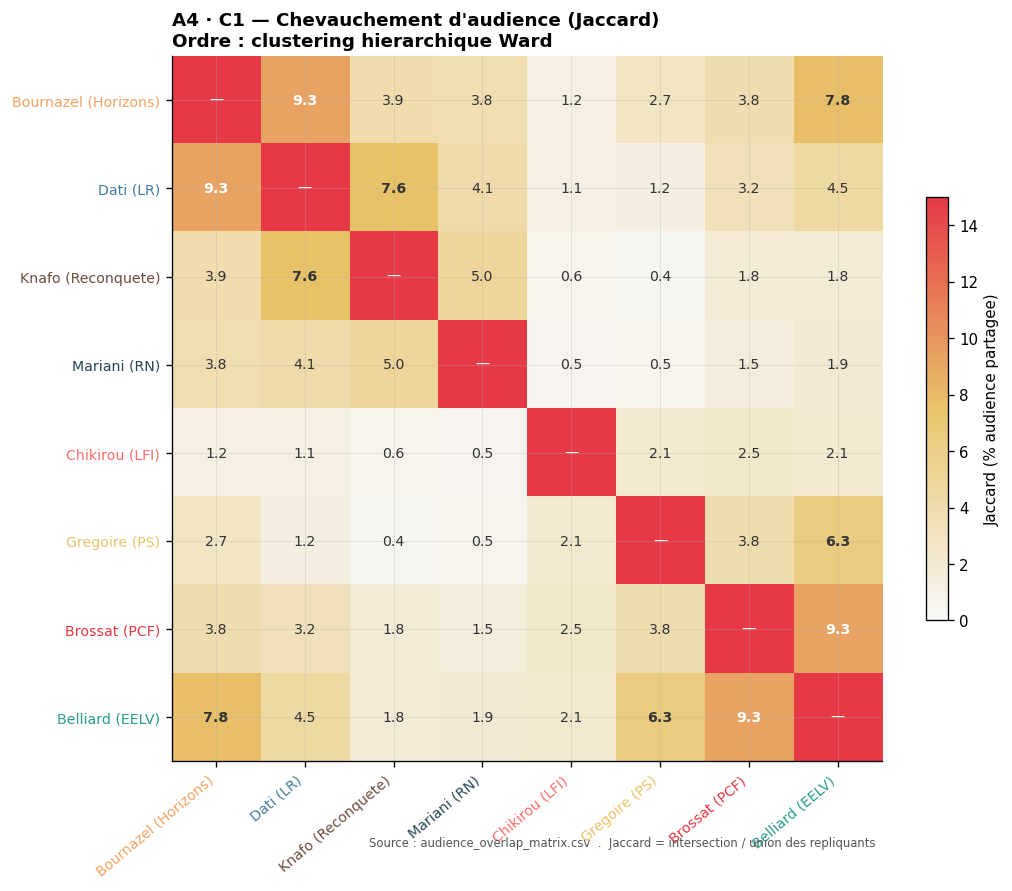

Figure C1 sauvegardee

JACCARD — DIAGNOSTICS

  Top 5 paires (audience la plus partagee) :
    Bournazel (Horizons)       × Dati (LR)                   Jaccard=9.3%  d_ideo=1
    Brossat (PCF)              × Belliard (EELV)             Jaccard=9.3%  d_ideo=2
    Bournazel (Horizons)       × Belliard (EELV)             Jaccard=7.8%  d_ideo=2
    Dati (LR)                  × Knafo (Reconquete)          Jaccard=7.6%  d_ideo=1
    Gregoire (PS)              × Belliard (EELV)             Jaccard=6.3%  d_ideo=1

  Bottom 5 paires (audience la plus distincte) :
    Dati (LR)                  × Chikirou (LFI)              Jaccard=1.1%  d_ideo=4
    Knafo (Reconquete)         × Chikirou (LFI)              Jaccard=0.6%  d_ideo=5
    Mariani (RN)               × Gregoire (PS)               Jaccard=0.5%  d_ideo=4
    Mariani (RN)               × Chikirou (LFI)              Jaccard=0.5%  d_ideo=6
    Knafo (Reconquete)         × Gregoire (PS)               Jaccard=0.4%  d_ideo=3

  Jaccard moyen in

In [2]:
# ============================================================
# A4 · Cellule 1 — Matrice Jaccard + Echo chamber scores
# C1a : Heatmap Jaccard 8x8 avec clustering hierarchique
# C1b : Diagnostics (paires max/min, profil par camp)
# ============================================================

# ── Load ────────────────────────────────────────────────────────────────────
jac_raw = pd.read_csv(DATA_A4 / 'audience_overlap_matrix.csv', index_col=0)
echo    = pd.read_csv(DATA_A4 / 'echo_chamber_scores.csv')
cross   = pd.read_csv(DATA_A4 / 'cross_candidate_mentions.csv')
comm    = pd.read_csv(DATA_A4 / 'community_membership.csv')

echo['key'] = echo['candidate_id'].map(ID_TO_KEY).fillna(echo['label'])

print("=" * 60)
print("CHARGEMENT A4")
print("=" * 60)
print(f"  Jaccard matrix  : {jac_raw.shape}")
print(f"  Echo scores     : {echo.shape}  | cols : {echo.columns.tolist()}")
print(f"  Cross mentions  : {cross.shape}")
print(f"  Community       : {comm.shape}")
print(f"\n  Echo chamber scores :")
for _, r in echo.sort_values('echo_score', ascending=False).iterrows():
    key = r['key']
    print(f"    {SHORT.get(key,key):<28}  echo={r['echo_score']:.1f}  "
          f"excl={r['exclusive_pct']:.1f}%  cross={r['cross_camp_pct']:.1f}%  "
          f"n={r['n_audience']:,}")

# ── Reorder Jaccard selon IDEO ─────────────────────────────────────────────
ORDRE_IDEO = sorted(IDEO.keys(), key=lambda k: IDEO[k])
jac_raw.index   = jac_raw.index.str.strip()
jac_raw.columns = jac_raw.columns.str.strip()
jac = jac_raw.loc[ORDRE_IDEO, ORDRE_IDEO]

# ── Clustering hierarchique (Ward) ─────────────────────────────────────────
dist_mat    = 1 - jac.values
np.fill_diagonal(dist_mat, 0)
dist_condensed = squareform(dist_mat, checks=False)
linkage_mat    = linkage(dist_condensed, method='ward')

from scipy.cluster.hierarchy import leaves_list
order_hclust   = leaves_list(linkage_mat)
keys_ordered   = [ORDRE_IDEO[i] for i in order_hclust]
jac_hclust     = jac.loc[keys_ordered, keys_ordered]

# ── Figure A : Heatmap Jaccard ─────────────────────────────────────────────
cmap_jac = LinearSegmentedColormap.from_list('jac', ['#F8F8F8','#E9C46A','#E63946'], N=256)

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(jac_hclust.values * 100, cmap=cmap_jac, vmin=0, vmax=15, aspect='auto')

n = len(keys_ordered)
for i in range(n):
    for j in range(n):
        v = jac_hclust.values[i, j] * 100
        txt_color = 'white' if v > 8 else '#333333'
        fmt = f'{v:.1f}' if i != j else '—'
        ax.text(j, i, fmt, ha='center', va='center', fontsize=8.5,
                color=txt_color, fontweight='bold' if (i != j and v > 5) else 'normal')

ax.set_xticks(range(n))
ax.set_yticks(range(n))
lbls = [SHORT.get(k, k) for k in keys_ordered]
ax.set_xticklabels(lbls, rotation=40, ha='right', fontsize=8.5)
ax.set_yticklabels(lbls, fontsize=8.5)

# Couleurs des labels selon camp
for tick, key in zip(ax.get_xticklabels(), keys_ordered):
    tick.set_color(COLORS.get(key, '#333333'))
for tick, key in zip(ax.get_yticklabels(), keys_ordered):
    tick.set_color(COLORS.get(key, '#333333'))

plt.colorbar(im, ax=ax, shrink=0.6, label='Jaccard (% audience partagee)')
ax.set_title('A4 · C1 — Chevauchement d\'audience (Jaccard)\nOrdre : clustering hierarchique Ward',
             fontsize=11, fontweight='bold', loc='left')
ax.text(0.99, -0.12,
        'Source : audience_overlap_matrix.csv  .  Jaccard = intersection / union des repliquants',
        transform=ax.transAxes, ha='right', fontsize=7, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A4_C1_jaccard_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C1 sauvegardee")

# ── Diagnostics ─────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("JACCARD — DIAGNOSTICS")
print("=" * 60)

# Paires off-diagonal
pairs = []
for i, k1 in enumerate(keys_ordered):
    for j, k2 in enumerate(keys_ordered):
        if j > i:
            v = jac_hclust.loc[k1, k2]
            pairs.append({'k1':k1, 'k2':k2,
                          'jac':v,
                          'dist_ideo': abs(IDEO[k1]-IDEO[k2]),
                          'same_camp': CAMP.get(k1)==CAMP.get(k2)})
pairs_df = pd.DataFrame(pairs).sort_values('jac', ascending=False)

print(f"\n  Top 5 paires (audience la plus partagee) :")
for _, r in pairs_df.head(5).iterrows():
    print(f"    {SHORT.get(r['k1'],r['k1']):<26} × {SHORT.get(r['k2'],r['k2']):<26}  "
          f"Jaccard={r['jac']*100:.1f}%  d_ideo={r['dist_ideo']}")

print(f"\n  Bottom 5 paires (audience la plus distincte) :")
for _, r in pairs_df.tail(5).iterrows():
    print(f"    {SHORT.get(r['k1'],r['k1']):<26} × {SHORT.get(r['k2'],r['k2']):<26}  "
          f"Jaccard={r['jac']*100:.1f}%  d_ideo={r['dist_ideo']}")

# Jaccard moyen inter/intra camp
intra = pairs_df[pairs_df['same_camp']]['jac'].mean()
inter = pairs_df[~pairs_df['same_camp']]['jac'].mean()
print(f"\n  Jaccard moyen intra-camp  : {intra*100:.2f}%")
print(f"  Jaccard moyen inter-camps : {inter*100:.2f}%")
print(f"  Ratio intra/inter         : {intra/inter:.2f}x")

pairs_df.to_csv(OUT / 'A4_jaccard_pairs.csv', index=False)
print(f"\nExport : outputs/A4_jaccard_pairs.csv  ({len(pairs_df)} paires)")


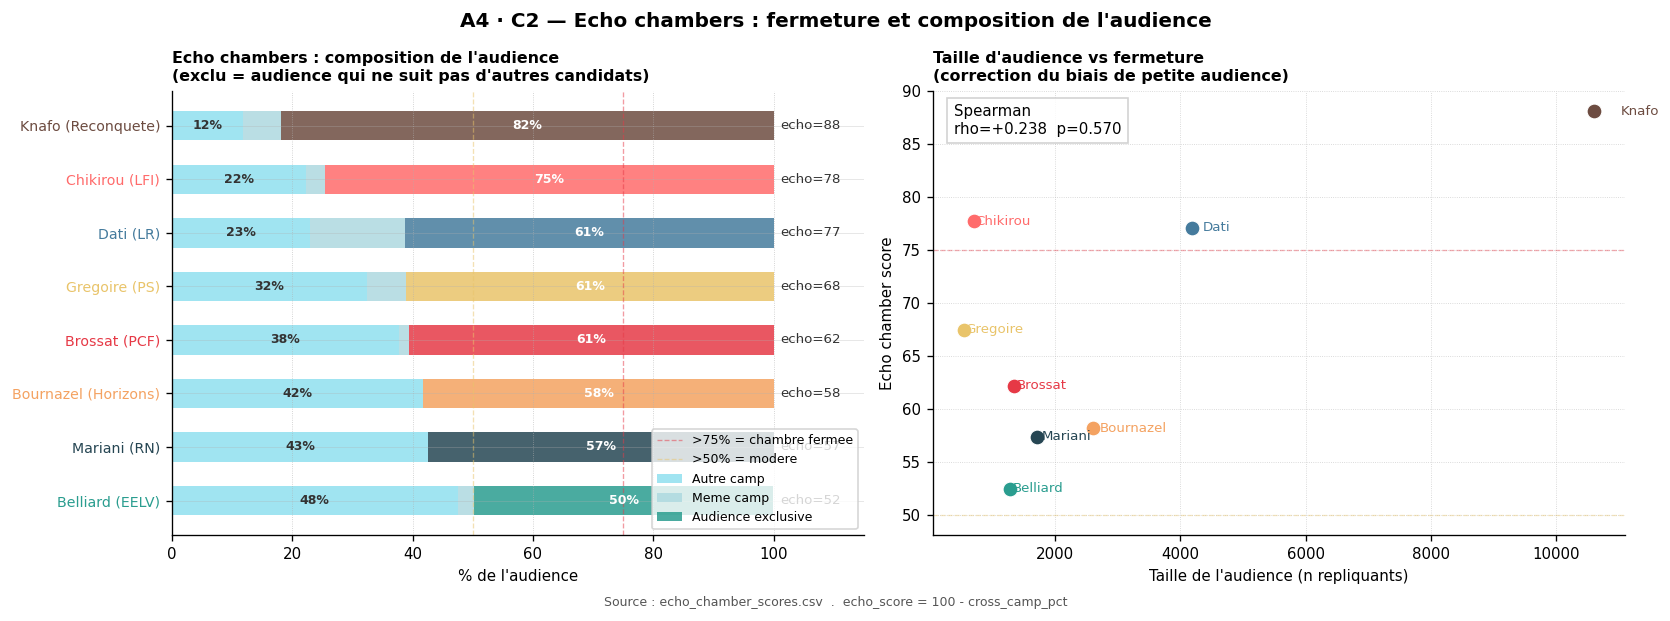

Figure C2 sauvegardee


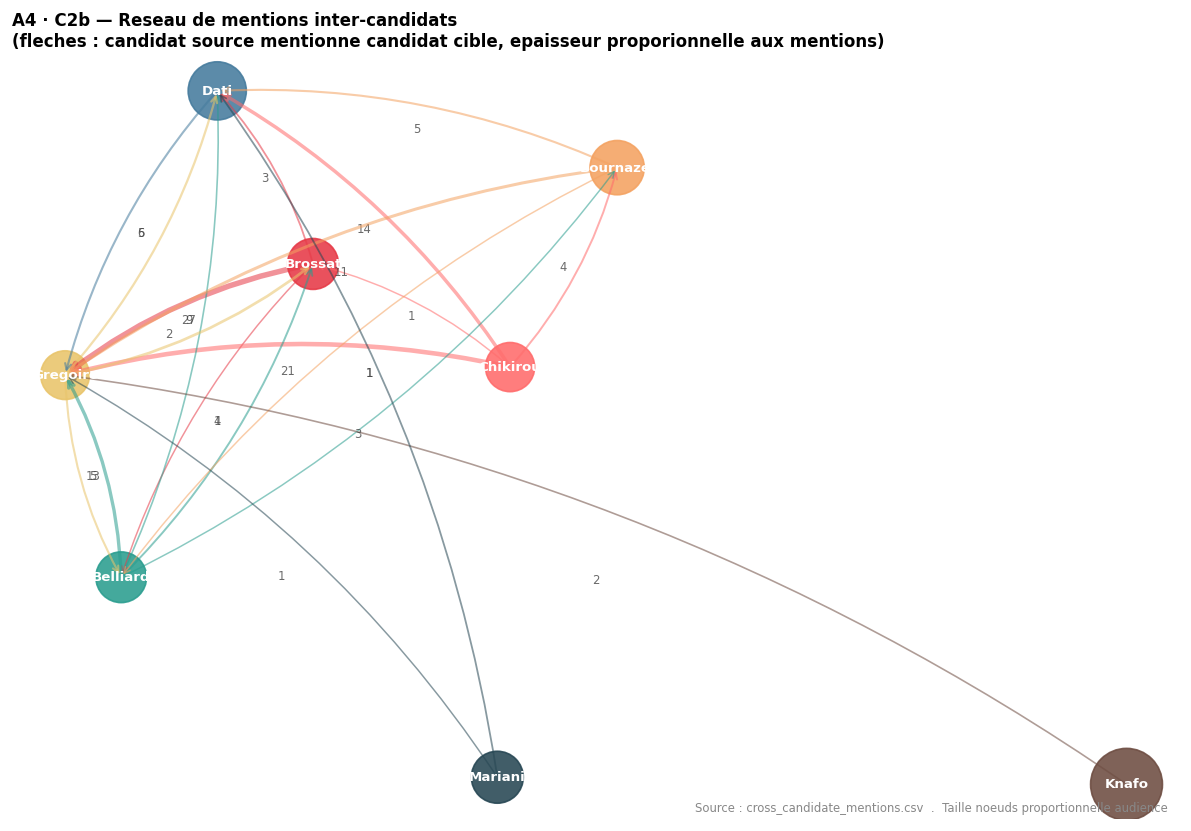

Figure C2b sauvegardee


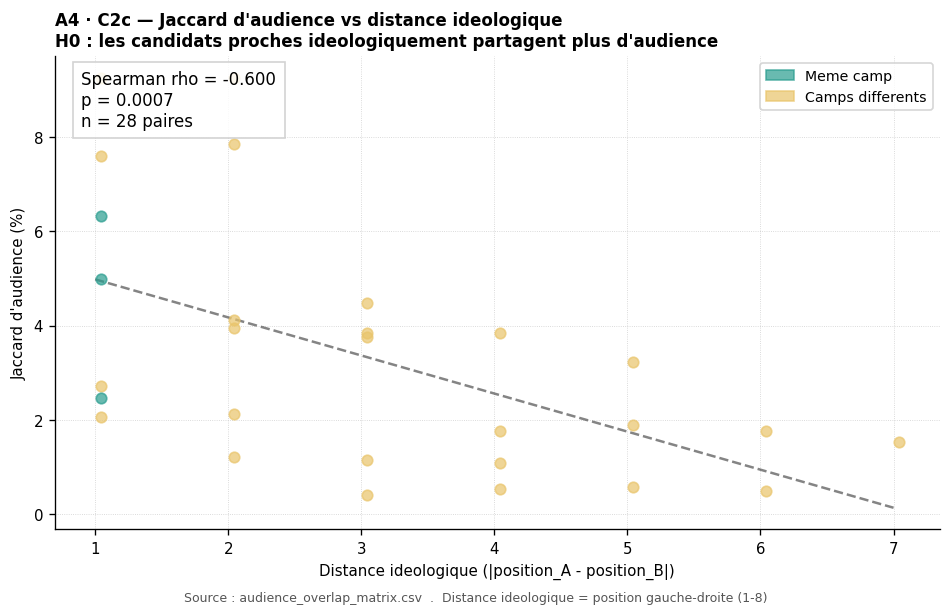

Figure C2c sauvegardee

C2c — TEST JACCARD <-> DISTANCE IDEOLOGIQUE
  Spearman rho = -0.600  p = 0.0007  n = 28
  -> Correlation negative significative
  -> CONFIRME H0 : + proches ideologiquement = + audience partagee

  Mentions inter-candidats : 21 paires
  Paire la plus active  : Brossat -> Gregoire (27 mentions)


In [3]:
# ============================================================
# A4 · Cellule 2 — Echo chamber scores + Reseau de mentions
# C2a : Barplot echo chamber (exclusive_pct / cross_camp_pct)
# C2b : Graphe force-directed des mentions inter-candidats
# C2c : Test Jaccard <-> distance ideologique (Spearman)
# ============================================================

from scipy import stats
import networkx as nx

# ── C2a : Barplot echo chambers ─────────────────────────────────────────────
echo_sorted = echo.sort_values('echo_score', ascending=True).copy()
echo_sorted['label_short'] = echo_sorted['key'].map(SHORT)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel gauche : stacked bar excl / same_camp / cross_camp
ax = axes[0]
keys_plot = echo_sorted['key'].tolist()
y_pos     = range(len(keys_plot))
colors_b  = [COLORS.get(k, '#888888') for k in keys_plot]

bars_cross = ax.barh(y_pos, echo_sorted['cross_camp_pct'], height=0.55,
                      color='#90E0EF', label='Autre camp', alpha=0.85)
bars_same  = ax.barh(y_pos, echo_sorted['same_camp_pct'],  height=0.55,
                      left=echo_sorted['cross_camp_pct'],
                      color='#AED9E0', label='Meme camp', alpha=0.85)
bars_excl  = ax.barh(y_pos, echo_sorted['exclusive_pct'],  height=0.55,
                      left=echo_sorted['cross_camp_pct'] + echo_sorted['same_camp_pct'],
                      color=[COLORS.get(k,'#888888') for k in keys_plot],
                      label='Audience exclusive', alpha=0.85)

# Annotation echo_score
for i, (_, r) in enumerate(echo_sorted.iterrows()):
    ax.text(101, i, f"echo={r['echo_score']:.0f}",
            va='center', ha='left', fontsize=8, color='#333333')
    ax.text(r['cross_camp_pct']/2, i,
            f"{r['cross_camp_pct']:.0f}%", va='center', ha='center',
            fontsize=7.5, color='#333333', fontweight='bold')
    ax.text(r['cross_camp_pct'] + r['same_camp_pct'] + r['exclusive_pct']/2, i,
            f"{r['exclusive_pct']:.0f}%", va='center', ha='center',
            fontsize=7.5, color='white', fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels([SHORT.get(k,k) for k in keys_plot], fontsize=8.5)
for tick, key in zip(ax.get_yticklabels(), keys_plot):
    tick.set_color(COLORS.get(key, '#333333'))
ax.set_xlabel('% de l\'audience', fontsize=9)
ax.set_xlim(0, 115)
ax.axvline(75, color='#E63946', lw=0.8, ls='--', alpha=0.5, label='>75% = chambre fermee')
ax.axvline(50, color='#E9C46A', lw=0.8, ls='--', alpha=0.5, label='>50% = modere')
ax.legend(fontsize=7.5, loc='lower right')
ax.set_title('Echo chambers : composition de l\'audience\n(exclu = audience qui ne suit pas d\'autres candidats)',
             fontsize=9.5, fontweight='bold', loc='left')
ax.grid(axis='x', ls=':', lw=0.5, alpha=0.7)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# Panel droit : scatter echo_score vs n_audience
ax2 = axes[1]
for _, r in echo.iterrows():
    key = r['key']
    ax2.scatter(r['n_audience'], r['echo_score'],
                color=COLORS.get(key,'#888888'), s=80, zorder=3,
                edgecolors='white', linewidths=0.7)
    ax2.text(r['n_audience'] * 1.04, r['echo_score'],
             SHORT.get(key,key).split(' ')[0],
             fontsize=8, color=COLORS.get(key,'#333333'), va='center')

# Spearman n_audience ~ echo_score
rho_e, p_e = stats.spearmanr(echo['n_audience'], echo['echo_score'])
ax2.text(0.03, 0.97,
         f'Spearman\nrho={rho_e:+.3f}  p={p_e:.3f}',
         transform=ax2.transAxes, va='top', fontsize=9,
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=4))
ax2.set_xlabel('Taille de l\'audience (n repliquants)', fontsize=9)
ax2.set_ylabel('Echo chamber score', fontsize=9)
ax2.set_title('Taille d\'audience vs fermeture\n(correction du biais de petite audience)',
             fontsize=9.5, fontweight='bold', loc='left')
ax2.axhline(75, color='#E63946', lw=0.8, ls='--', alpha=0.4)
ax2.axhline(50, color='#E9C46A', lw=0.8, ls='--', alpha=0.4)
ax2.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)

fig.suptitle('A4 · C2 — Echo chambers : fermeture et composition de l\'audience',
             fontsize=12, fontweight='bold')
fig.text(0.5, -0.01,
         'Source : echo_chamber_scores.csv  .  echo_score = 100 - cross_camp_pct',
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A4_C2_echo_chambers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C2 sauvegardee")

# ── C2b : Reseau force-directed mentions inter-candidats ─────────────────────
cross   = pd.read_csv(DATA_A4 / 'cross_candidate_mentions.csv')
cross['k_source'] = cross['source_label']
cross['k_target'] = cross['target_label']

G = nx.DiGraph()
for k in IDEO.keys():
    G.add_node(k)
for _, r in cross.iterrows():
    ks, kt = r['k_source'], r['k_target']
    if ks in IDEO and kt in IDEO:
        G.add_edge(ks, kt, weight=r['mentions'])

pos = nx.spring_layout(G, seed=42, k=2.5)

fig3, ax3 = plt.subplots(figsize=(10, 7))
ax3.set_facecolor('#FAFAFA')

edge_weights = [G[u][v]['weight'] for u,v in G.edges()]
w_max        = max(edge_weights) if edge_weights else 1

for (u, v), w in zip(G.edges(), edge_weights):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    ax3.annotate('', xy=(x1,y1), xytext=(x0,y0),
                 arrowprops=dict(
                     arrowstyle='->', color=COLORS.get(u,'#888888'),
                     lw=0.8 + 2.5*(w/w_max), alpha=0.55,
                     connectionstyle='arc3,rad=0.12'))
    mx, my = (x0+x1)/2, (y0+y1)/2
    ax3.text(mx, my, str(w), fontsize=7, ha='center', va='center',
             color='#444444', alpha=0.8)

node_sizes = {k: 800 + echo.set_index('key')['n_audience'].get(k, 500)//10
              for k in IDEO.keys() if k in pos}
nx.draw_networkx_nodes(G, pos, ax=ax3,
                       node_size=[node_sizes.get(k, 800) for k in G.nodes()],
                       node_color=[COLORS.get(k,'#888888') for k in G.nodes()],
                       alpha=0.88)
nx.draw_networkx_labels(G, pos, ax=ax3,
                        labels={k: SHORT.get(k,k).split(' ')[0] for k in G.nodes()},
                        font_size=8, font_color='white', font_weight='bold')

ax3.set_title('A4 · C2b — Reseau de mentions inter-candidats\n'
              '(fleches : candidat source mentionne candidat cible, epaisseur proporionnelle aux mentions)',
              fontsize=10, fontweight='bold', loc='left')
ax3.text(0.99, 0.01, 'Source : cross_candidate_mentions.csv  .  Taille noeuds proportionnelle audience',
         transform=ax3.transAxes, ha='right', fontsize=7, color='#888888')
ax3.axis('off')
plt.tight_layout()
fig3.savefig(OUT / 'A4_C2b_mentions_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C2b sauvegardee")

# ── C2c : Test Jaccard <-> distance ideologique ──────────────────────────────
pairs_df = pd.read_csv(OUT / 'A4_jaccard_pairs.csv')
rho_j, p_j = stats.spearmanr(pairs_df['dist_ideo'], pairs_df['jac'])

fig4, ax4 = plt.subplots(figsize=(8, 5))
for _, r in pairs_df.iterrows():
    jitter_x = np.random.default_rng(42).uniform(-0.08, 0.08)
    col = '#2A9D8F' if r['same_camp'] else '#E9C46A'
    ax4.scatter(r['dist_ideo'] + jitter_x, r['jac']*100, color=col,
                s=40, alpha=0.70, zorder=3)

# Trend line
x_ = pairs_df['dist_ideo'].values
y_ = pairs_df['jac'].values * 100
m, b = np.polyfit(x_, y_, 1)
xr  = np.linspace(x_.min(), x_.max(), 100)
ax4.plot(xr, m*xr + b, '--', lw=1.5, color='#333333', alpha=0.6)

ax4.text(0.03, 0.97,
         f'Spearman rho = {rho_j:+.3f}\np = {p_j:.4f}\nn = {len(pairs_df)} paires',
         transform=ax4.transAxes, va='top', fontsize=10,
         bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=5))

p1 = mpatches.Patch(color='#2A9D8F', label='Meme camp', alpha=0.7)
p2 = mpatches.Patch(color='#E9C46A', label='Camps differents', alpha=0.7)
ax4.legend(handles=[p1,p2], fontsize=8.5)

ax4.set_xlabel('Distance ideologique (|position_A - position_B|)', fontsize=9)
ax4.set_ylabel('Jaccard d\'audience (%)', fontsize=9)
ax4.set_title('A4 · C2c — Jaccard d\'audience vs distance ideologique\n'
              'H0 : les candidats proches ideologiquement partagent plus d\'audience',
              fontsize=10, fontweight='bold', loc='left')
ax4.grid(ls=':', lw=0.5, alpha=0.6)
for sp in ['top','right']: ax4.spines[sp].set_visible(False)
fig4.text(0.5, -0.01,
          'Source : audience_overlap_matrix.csv  .  Distance ideologique = position gauche-droite (1-8)',
          ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig4.savefig(OUT / 'A4_C2c_jaccard_ideo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C2c sauvegardee")

print("\n" + "=" * 60)
print("C2c — TEST JACCARD <-> DISTANCE IDEOLOGIQUE")
print("=" * 60)
print(f"  Spearman rho = {rho_j:+.3f}  p = {p_j:.4f}  n = {len(pairs_df)}")
if p_j < 0.05:
    interp = "negative" if rho_j < 0 else "positive"
    print(f"  -> Correlation {interp} significative")
    if rho_j < 0:
        print("  -> CONFIRME H0 : + proches ideologiquement = + audience partagee")
    else:
        print("  -> INFIRME H0 : distance ideologique n'explique pas l'overlap")
else:
    print("  -> Pas de correlation significative (H0 non confirmee)")
print(f"\n  Mentions inter-candidats : {len(cross)} paires")
print(f"  Paire la plus active  : "
      f"{cross.sort_values('mentions',ascending=False).iloc[0]['source_label']} -> "
      f"{cross.sort_values('mentions',ascending=False).iloc[0]['target_label']} "
      f"({cross['mentions'].max()} mentions)")


A3_nsi_by_candidate cols: ['key', 'label', 'nsi', 'ci_lo', 'ci_hi', 'n', 'n_host', 'n_sout', 'host_pct']
        key            label       nsi     ci_lo     ci_hi     n  n_host  n_sout   host_pct
0  Chikirou   Chikirou (LFI) -0.250941 -0.298651 -0.202008   797     316     116  39.648683
1   Brossat    Brossat (PCF) -0.208675 -0.238584 -0.178781  1706     561     205  32.883939
2  Belliard  Belliard (EELV) -0.132664 -0.160161 -0.107796  1892     495     244  26.162791

Merge echo x sentiment : 8 candidats
      key  echo_score  pct_hostilite  pct_ironie   nsi_mean
    Knafo        88.1      20.142800    8.782800  15.420000
 Chikirou        77.7      35.829444   16.251111 -29.862222
     Dati        77.1      19.711429    8.398095   2.036190
 Gregoire        67.5       9.231579    8.788421  19.586842
  Brossat        62.2      36.818889    9.728889 -24.812778
Bournazel        58.2      14.083571    7.147143  16.871429
  Mariani        57.4      25.441000    4.734000  -1.699000
 Belliard

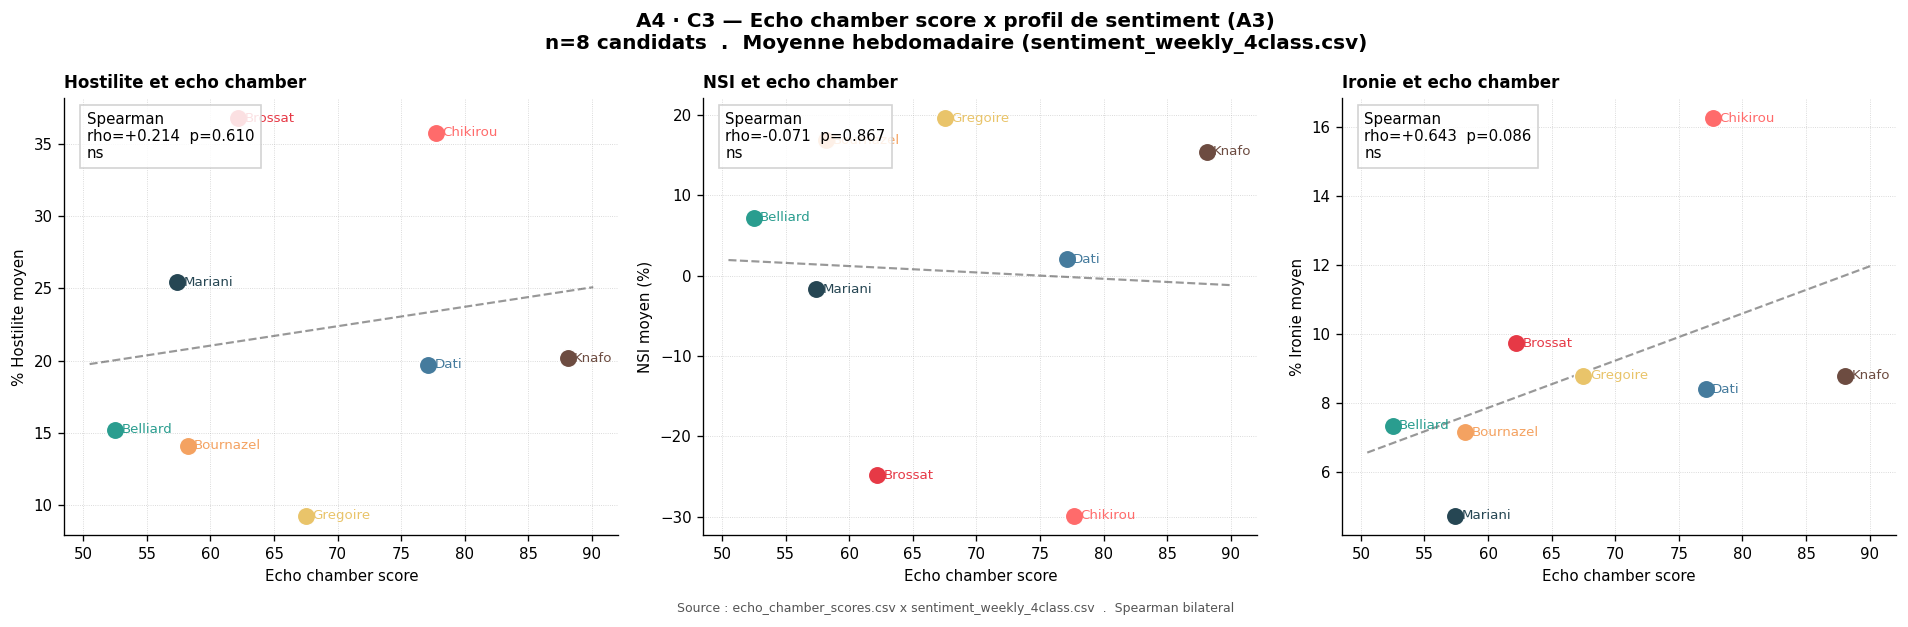

Figure C3 sauvegardee

C3 — ECHO CHAMBER x SENTIMENT (Spearman, n=8 candidats)
  echo_score ~ pct_hostilite : rho=+0.214  p=0.6103  ns
  echo_score ~ NSI           : rho=-0.071  p=0.8665  ns
  echo_score ~ pct_ironie    : rho=+0.643  p=0.0856  ns

  Interpretation :
  -> Pas de correlation significative echo <-> hostilite (n=8 limite la puissance)

  Candidat                     echo   host%    nsi%   iro%  Camp
  ------------------------------------------------------------
  Knafo (Reconquete)           88.1    20.1   +15.4    8.8  Extreme droite
  Chikirou (LFI)               77.7    35.8   -29.9   16.3  Extreme gauche
  Dati (LR)                    77.1    19.7    +2.0    8.4  Droite
  Gregoire (PS)                67.5     9.2   +19.6    8.8  Gauche
  Brossat (PCF)                62.2    36.8   -24.8    9.7  Extreme gauche
  Bournazel (Horizons)         58.2    14.1   +16.9    7.1  Centre
  Mariani (RN)                 57.4    25.4    -1.7    4.7  Extreme droite
  Belliard (EELV)   

In [4]:
# ============================================================
# A4 · Cellule 3 — Croisement A4 x A3 : Echo chamber x Hostilite
# C3a : echo_score x pct_hostilite / NSI (scatter Spearman, n=8)
# C3b : echo_score x pct_ironie
# C3c : table de synthese echo x sentiment
# ============================================================

from scipy import stats
import unicodedata

def strip_accents(s):
    return ''.join(c for c in unicodedata.normalize('NFD', str(s))
                   if unicodedata.category(c) != 'Mn')

# ── Load echo scores ─────────────────────────────────────────────────────────
echo = pd.read_csv(DATA_A4 / 'echo_chamber_scores.csv')
echo['key'] = echo['candidate_id'].map(ID_TO_KEY).fillna(echo['label'])

# ── Load sentiment A3 : NSI CSV + sentiment_weekly pour pct_hostilite/ironie ─
# Mapping ID A3 (format replies)
ID_TO_KEY_A3 = {
    'pierre_yves_brossat':'Brossat', 'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',     'lea_gregoire':'Gregoire',
    'victor_bournazel':'Bournazel',  'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',           'thierry_mariani':'Mariani'
}

sw = pd.read_csv(Path('..') / 'A3_sentiment' / 'data' / 'sentiment_weekly_4class.csv')
sw['key'] = sw['candidate_id'].map(ID_TO_KEY_A3)
unmapped  = sw['key'].isna()
if unmapped.any():
    sw.loc[unmapped, 'key'] = sw.loc[unmapped, 'candidate'].apply(strip_accents)

# Moyenne par candidat (toutes semaines)
cand_sent = (sw.groupby('key')
               .agg(pct_hostilite=('pct_hostilite','mean'),
                    pct_soutien  =('pct_soutien',  'mean'),
                    pct_ironie   =('pct_ironie',   'mean'),
                    nsi_mean     =('net_support',   'mean'))
               .reset_index())

# NSI bootstrap depuis A3 export (IC 95%)
nsi_path = Path('..') / 'A3_sentiment' / 'outputs' / 'A3_nsi_by_candidate.csv'
nsi_df   = pd.read_csv(nsi_path)
print("A3_nsi_by_candidate cols:", nsi_df.columns.tolist())
print(nsi_df.head(3).to_string())

# Fusion echo x sentiment
merged = echo.merge(cand_sent, on='key', how='inner')
print(f"\nMerge echo x sentiment : {len(merged)} candidats")
print(merged[['key','echo_score','pct_hostilite','pct_ironie','nsi_mean']].to_string(index=False))

# ── Tests Spearman ────────────────────────────────────────────────────────────
rho_h, p_h = stats.spearmanr(merged['echo_score'], merged['pct_hostilite'])
rho_n, p_n = stats.spearmanr(merged['echo_score'], merged['nsi_mean'])
rho_i, p_i = stats.spearmanr(merged['echo_score'], merged['pct_ironie'])

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

targets = [
    ('pct_hostilite', '% Hostilite moyen', rho_h, p_h, 'Hostilite et echo chamber'),
    ('nsi_mean',      'NSI moyen (%)',      rho_n, p_n, 'NSI et echo chamber'),
    ('pct_ironie',    '% Ironie moyen',     rho_i, p_i, 'Ironie et echo chamber'),
]

for ax, (col, ylabel, rho, p, title) in zip(axes, targets):
    for _, r in merged.iterrows():
        key = r['key']
        ax.scatter(r['echo_score'], r[col],
                   color=COLORS.get(key,'#888888'), s=120, zorder=3,
                   edgecolors='white', linewidths=0.8)
        ax.text(r['echo_score'] + 0.5, r[col],
                SHORT.get(key, key).split(' ')[0],
                fontsize=8, va='center', color=COLORS.get(key,'#333333'))

    # Trend
    x_ = merged['echo_score'].values
    y_ = merged[col].values
    if len(x_) >= 3:
        m, b = np.polyfit(x_, y_, 1)
        xr   = np.linspace(x_.min()-2, x_.max()+2, 100)
        ax.plot(xr, m*xr + b, '--', lw=1.3, color='#333333', alpha=0.5)

    sig = '✓ Sig.' if p < 0.05 else 'ns'
    ax.text(0.04, 0.97,
            f'Spearman\nrho={rho:+.3f}  p={p:.3f}\n{sig}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(facecolor='white', edgecolor='#CCCCCC', alpha=0.85, pad=4))

    ax.set_xlabel('Echo chamber score', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold', loc='left')
    ax.grid(ls=':', lw=0.5, alpha=0.6)
    for sp in ['top','right']: ax.spines[sp].set_visible(False)

fig.suptitle('A4 · C3 — Echo chamber score x profil de sentiment (A3)\n'
             'n=8 candidats  .  Moyenne hebdomadaire (sentiment_weekly_4class.csv)',
             fontsize=12, fontweight='bold')
fig.text(0.5, -0.02,
         'Source : echo_chamber_scores.csv x sentiment_weekly_4class.csv  .  Spearman bilateral',
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A4_C3_echo_x_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C3 sauvegardee")

print("\n" + "=" * 65)
print("C3 — ECHO CHAMBER x SENTIMENT (Spearman, n=8 candidats)")
print("=" * 65)
print(f"  echo_score ~ pct_hostilite : rho={rho_h:+.3f}  p={p_h:.4f}  {'*' if p_h<0.05 else 'ns'}")
print(f"  echo_score ~ NSI           : rho={rho_n:+.3f}  p={p_n:.4f}  {'*' if p_n<0.05 else 'ns'}")
print(f"  echo_score ~ pct_ironie    : rho={rho_i:+.3f}  p={p_i:.4f}  {'*' if p_i<0.05 else 'ns'}")
print("\n  Interpretation :")
if p_h < 0.05:
    print(f"  -> echo_score ~ hostilite {'positif' if rho_h>0 else 'negatif'} : "
          f"les audiences {'plus fermees' if rho_h>0 else 'plus ouvertes'} recoivent "
          f"{'plus' if rho_h>0 else 'moins'} d'hostilite")
else:
    print("  -> Pas de correlation significative echo <-> hostilite (n=8 limite la puissance)")
if p_n < 0.05:
    print(f"  -> echo_score ~ NSI {'positif' if rho_n>0 else 'negatif'} : "
          f"les audiences {'fermees' if rho_n>0 else 'ouvertes'} ont un NSI "
          f"{'plus eleve' if rho_n>0 else 'plus bas'}")
print()

# Table synthese
print(f"  {'Candidat':<26} {'echo':>6} {'host%':>7} {'nsi%':>7} {'iro%':>6}  Camp")
print("  " + "-" * 60)
for _, r in merged.sort_values('echo_score', ascending=False).iterrows():
    key = r['key']
    print(f"  {SHORT.get(key,key):<26} {r['echo_score']:>6.1f} "
          f"{r['pct_hostilite']:>7.1f} {r['nsi_mean']:>+7.1f} "
          f"{r['pct_ironie']:>6.1f}  {CAMP.get(key,'?')}")

# Export
merged[['key','echo_score','exclusive_pct','cross_camp_pct','n_audience',
        'pct_hostilite','pct_ironie','nsi_mean']].to_csv(
    OUT / 'A4_echo_x_sentiment.csv', index=False)
print(f"\nExport : outputs/A4_echo_x_sentiment.csv")


COMMUNITY MEMBERSHIP — DIAGNOSTICS
  Utilisateurs multi-candidats : 2,963
  n_candidates_engaged range   : 2 → 7

  Distribution n_candidates_engaged :
    2 candidats : 2,210  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
    3 candidats :   553  |||||||||||||||||||||||||||
    4 candidats :   153  |||||||
    5 candidats :    35  |
    6 candidats :    10  
    7 candidats :     2  

  Candidat dominant le plus frequent :
    Knafo (Reconquete)           1,260  (42.5%)
    Dati (LR)                      655  (22.1%)
    Bournazel (Horizons)           355  (12.0%)
    Mariani (RN)                   283  (9.6%)
    Belliard (EELV)                146  (4.9%)
    Brossat (PCF)                  145  (4.9%)
    Chikirou (LFI)                  79  (2.7%)
    Gregoire (PS)                   40  (1.3%)


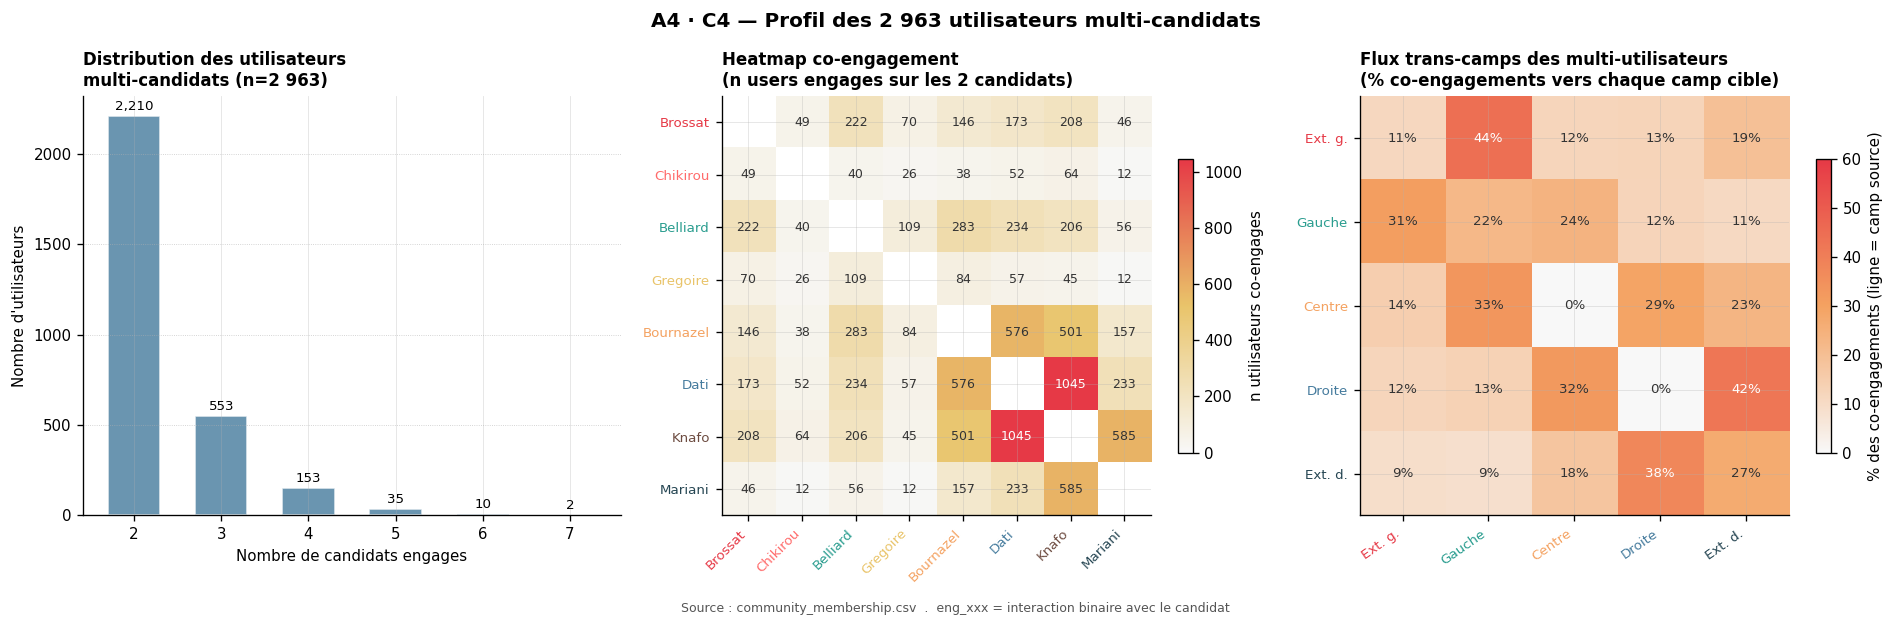

Figure C4 sauvegardee

C4 — UTILISATEURS MULTI-CANDIDATS
  Total          : 2,963 utilisateurs
  n=2 candidats  : 2,210  (74.6%)
  n>=3 candidats : 753  (25.4%)
  n>=4 candidats : 200  (6.7%)

  Utilisateurs trans-camp    : 2,537  (85.6%)
  Utilisateurs mono-camp     : 426  (14.4%)

  Top co-engagements (n paires) :
    Dati (LR)                  x Knafo (Reconquete)         : 1,045 users
    Knafo (Reconquete)         x Mariani (RN)               :   585 users
    Bournazel (Horizons)       x Dati (LR)                  :   576 users
    Bournazel (Horizons)       x Knafo (Reconquete)         :   501 users
    Belliard (EELV)            x Bournazel (Horizons)       :   283 users
    Belliard (EELV)            x Dati (LR)                  :   234 users
    Dati (LR)                  x Mariani (RN)               :   233 users
    Belliard (EELV)            x Brossat (PCF)              :   222 users

A4 — EXPORTS GENERES
  OK  A4_C1_jaccard_heatmap.png                134 Ko
  OK  A4_C2_ec

In [5]:
# ============================================================
# A4 · Cellule 4 — Utilisateurs multi-candidats
# C4a : distribution n_candidates_engaged
# C4b : heatmap co-engagement candidat x candidat
# C4c : profil camp des utilisateurs trans-camps
# C4d : synthese + export A4
# ============================================================

comm = pd.read_csv(DATA_A4 / 'community_membership.csv')

# Mapping dominant_candidate -> key
DOM_MAP = {
    'ian_brossat':'Brossat',               'sophia_chikirou':'Chikirou',
    'david_belliard':'Belliard',           'emmanuel_gregoire':'Gregoire',
    'pierre_yves_bournazel':'Bournazel',   'rachida_dati':'Dati',
    'sarah_knafo':'Knafo',                 'thierry_mariani':'Mariani'
}
comm['key_dom'] = comm['dominant_candidate'].map(DOM_MAP)

print("=" * 60)
print("COMMUNITY MEMBERSHIP — DIAGNOSTICS")
print("=" * 60)
print(f"  Utilisateurs multi-candidats : {len(comm):,}")
print(f"  n_candidates_engaged range   : {comm['n_candidates_engaged'].min()}"
      f" → {comm['n_candidates_engaged'].max()}")
print(f"\n  Distribution n_candidates_engaged :")
for n, cnt in comm['n_candidates_engaged'].value_counts().sort_index().items():
    bar = '|' * int(cnt/20)
    print(f"    {n} candidats : {cnt:>5,}  {bar}")

print(f"\n  Candidat dominant le plus frequent :")
for k, cnt in comm['key_dom'].value_counts().items():
    pct = 100*cnt/len(comm)
    print(f"    {SHORT.get(k,k):<28} {cnt:>5,}  ({pct:.1f}%)")

# ── Colonne dominant_camp ─────────────────────────────────────────────────────
comm['camp_dom'] = comm['key_dom'].map(CAMP)

# Trans-camp users : n_candidates_engaged > 1 implique au moins 2 candidats
# Verifier si leur camp dominant differe d'un camp secondaire via candidates_list
ENG_COLS = [c for c in comm.columns if c.startswith('eng_')]
KEY_COLS  = {c: DOM_MAP.get(c.replace('eng_',''),'?') for c in ENG_COLS}

# ── C4a : Histogramme distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
counts = comm['n_candidates_engaged'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values,
              color='#457B9D', alpha=0.80, width=0.6, edgecolor='white')
for bar, cnt in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{cnt:,}', ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Nombre de candidats engages', fontsize=9)
ax.set_ylabel('Nombre d\'utilisateurs', fontsize=9)
ax.set_title('Distribution des utilisateurs\nmulti-candidats (n=2 963)',
             fontsize=10, fontweight='bold', loc='left')
ax.grid(axis='y', ls=':', lw=0.5, alpha=0.7)
for sp in ['top','right']: ax.spines[sp].set_visible(False)

# ── C4b : Heatmap co-engagement ─────────────────────────────────────────────
ax2 = axes[1]
# Matrice de co-engagement : n utilisateurs qui ont eng_A=1 ET eng_B=1
keys_order = list(IDEO.keys())
co_mat     = pd.DataFrame(0, index=keys_order, columns=keys_order, dtype=float)

eng_key_map = {}
for ecol in ENG_COLS:
    cid = ecol.replace('eng_','')
    mapped = DOM_MAP.get(cid)
    if mapped:
        eng_key_map[mapped] = ecol

for k1 in keys_order:
    for k2 in keys_order:
        if k1 == k2:
            co_mat.loc[k1,k2] = np.nan
            continue
        c1 = eng_key_map.get(k1)
        c2 = eng_key_map.get(k2)
        if c1 and c2:
            co = (comm[c1] & comm[c2]).sum()
            co_mat.loc[k1,k2] = co

from matplotlib.colors import LinearSegmentedColormap
cmap_co = LinearSegmentedColormap.from_list('co',['#F8F8F8','#E9C46A','#E63946'],N=256)
im2 = ax2.imshow(co_mat.values.astype(float), cmap=cmap_co, aspect='auto',
                  vmin=0, vmax=np.nanmax(co_mat.values))

for i, k1 in enumerate(keys_order):
    for j, k2 in enumerate(keys_order):
        v = co_mat.loc[k1,k2]
        if pd.notna(v):
            txt_col = 'white' if v > np.nanmax(co_mat.values)*0.6 else '#333333'
            ax2.text(j, i, f'{int(v)}', ha='center', va='center',
                     fontsize=7.5, color=txt_col)

ax2.set_xticks(range(len(keys_order)))
ax2.set_yticks(range(len(keys_order)))
lbls = [SHORT.get(k,k).split(' ')[0] for k in keys_order]
ax2.set_xticklabels(lbls, rotation=45, ha='right', fontsize=8)
ax2.set_yticklabels(lbls, fontsize=8)
for tick, key in zip(ax2.get_xticklabels(), keys_order):
    tick.set_color(COLORS.get(key,'#333333'))
for tick, key in zip(ax2.get_yticklabels(), keys_order):
    tick.set_color(COLORS.get(key,'#333333'))
plt.colorbar(im2, ax=ax2, shrink=0.7, label='n utilisateurs co-engages')
ax2.set_title('Heatmap co-engagement\n(n users engages sur les 2 candidats)',
              fontsize=10, fontweight='bold', loc='left')

# ── C4c : Camp des utilisateurs trans-camps ──────────────────────────────────
ax3 = axes[2]
# Pour chaque candidat dominant : combien d'utilisateurs vont vers chaque autre camp ?
camp_cross = {}
for key_dom, grp in comm.groupby('key_dom'):
    camp_d = CAMP.get(key_dom, '?')
    for ecol in ENG_COLS:
        k_other = DOM_MAP.get(ecol.replace('eng_',''))
        if k_other and k_other != key_dom:
            camp_other = CAMP.get(k_other,'?')
            n_cross    = grp[ecol].sum()
            camp_cross[(camp_d, camp_other)] = camp_cross.get((camp_d,camp_other),0) + n_cross

# Convertir en matrice camps
camps_uniq = ['Extreme gauche','Gauche','Centre','Droite','Extreme droite']
camp_mat   = pd.DataFrame(0, index=camps_uniq, columns=camps_uniq, dtype=float)
for (c1,c2), v in camp_cross.items():
    if c1 in camps_uniq and c2 in camps_uniq:
        camp_mat.loc[c1,c2] += v

# Normaliser par ligne (% du camp source)
camp_mat_norm = camp_mat.div(camp_mat.sum(axis=1).replace(0,np.nan), axis=0) * 100

cmap_camp = LinearSegmentedColormap.from_list('camp',['#F8F8F8','#F4A261','#E63946'],N=256)
im3 = ax3.imshow(camp_mat_norm.values, cmap=cmap_camp, aspect='auto', vmin=0, vmax=60)
for i, c1 in enumerate(camps_uniq):
    for j, c2 in enumerate(camps_uniq):
        v = camp_mat_norm.loc[c1,c2]
        txt_col = 'white' if v > 35 else '#333333'
        ax3.text(j, i, f'{v:.0f}%', ha='center', va='center',
                 fontsize=8, color=txt_col)

ax3.set_xticks(range(len(camps_uniq)))
ax3.set_yticks(range(len(camps_uniq)))
short_camps = ['Ext. g.','Gauche','Centre','Droite','Ext. d.']
ax3.set_xticklabels(short_camps, rotation=35, ha='right', fontsize=8)
ax3.set_yticklabels(short_camps, fontsize=8)
for tick, camp in zip(ax3.get_xticklabels(), camps_uniq):
    tick.set_color(CAMP_COLOR.get(camp,'#333333'))
for tick, camp in zip(ax3.get_yticklabels(), camps_uniq):
    tick.set_color(CAMP_COLOR.get(camp,'#333333'))
plt.colorbar(im3, ax=ax3, shrink=0.7, label='% des co-engagements (ligne = camp source)')
ax3.set_title('Flux trans-camps des multi-utilisateurs\n(% co-engagements vers chaque camp cible)',
              fontsize=10, fontweight='bold', loc='left')

fig.suptitle('A4 · C4 — Profil des 2 963 utilisateurs multi-candidats',
             fontsize=12, fontweight='bold')
fig.text(0.5, -0.02,
         'Source : community_membership.csv  .  eng_xxx = interaction binaire avec le candidat',
         ha='center', fontsize=7.5, color='#555555')
plt.tight_layout()
fig.savefig(OUT / 'A4_C4_multi_users.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure C4 sauvegardee")

# ── Diagnostics texte ────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("C4 — UTILISATEURS MULTI-CANDIDATS")
print("=" * 65)
print(f"  Total          : {len(comm):,} utilisateurs")
print(f"  n=2 candidats  : {(comm['n_candidates_engaged']==2).sum():,}  "
      f"({100*(comm['n_candidates_engaged']==2).mean():.1f}%)")
print(f"  n>=3 candidats : {(comm['n_candidates_engaged']>=3).sum():,}  "
      f"({100*(comm['n_candidates_engaged']>=3).mean():.1f}%)")
print(f"  n>=4 candidats : {(comm['n_candidates_engaged']>=4).sum():,}  "
      f"({100*(comm['n_candidates_engaged']>=4).mean():.1f}%)")

# Fraction trans-camp
trans_camp = 0
for _, row in comm.iterrows():
    cands_eng = [DOM_MAP.get(ecol.replace('eng_',''))
                 for ecol in ENG_COLS if row[ecol] == 1
                 and DOM_MAP.get(ecol.replace('eng_',''))]
    camps_eng = set(CAMP.get(k,'?') for k in cands_eng if k)
    if len(camps_eng) > 1:
        trans_camp += 1

pct_trans = 100 * trans_camp / len(comm)
print(f"\n  Utilisateurs trans-camp    : {trans_camp:,}  ({pct_trans:.1f}%)")
print(f"  Utilisateurs mono-camp     : {len(comm)-trans_camp:,}  ({100-pct_trans:.1f}%)")
print(f"\n  Top co-engagements (n paires) :")
co_pairs = []
for k1 in keys_order:
    for k2 in keys_order:
        if k1 < k2:
            v = co_mat.loc[k1,k2]
            if pd.notna(v) and v > 0:
                co_pairs.append((k1,k2,int(v)))
co_pairs.sort(key=lambda x:-x[2])
for k1,k2,v in co_pairs[:8]:
    print(f"    {SHORT.get(k1,k1):<26} x {SHORT.get(k2,k2):<26} : {v:>5,} users")

# ── Export final A4 ──────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("A4 — EXPORTS GENERES")
print("=" * 65)
exports = [
    'A4_C1_jaccard_heatmap.png',
    'A4_C2_echo_chambers.png',
    'A4_C2b_mentions_network.png',
    'A4_C2c_jaccard_ideo.png',
    'A4_C3_echo_x_sentiment.png',
    'A4_C4_multi_users.png',
    'A4_jaccard_pairs.csv',
    'A4_echo_x_sentiment.csv',
]
for f in exports:
    status = 'OK' if (OUT/f).exists() else 'MANQUANT'
    size   = f'{(OUT/f).stat().st_size//1024} Ko' if (OUT/f).exists() else ''
    print(f"  {status}  {f:<40} {size}")


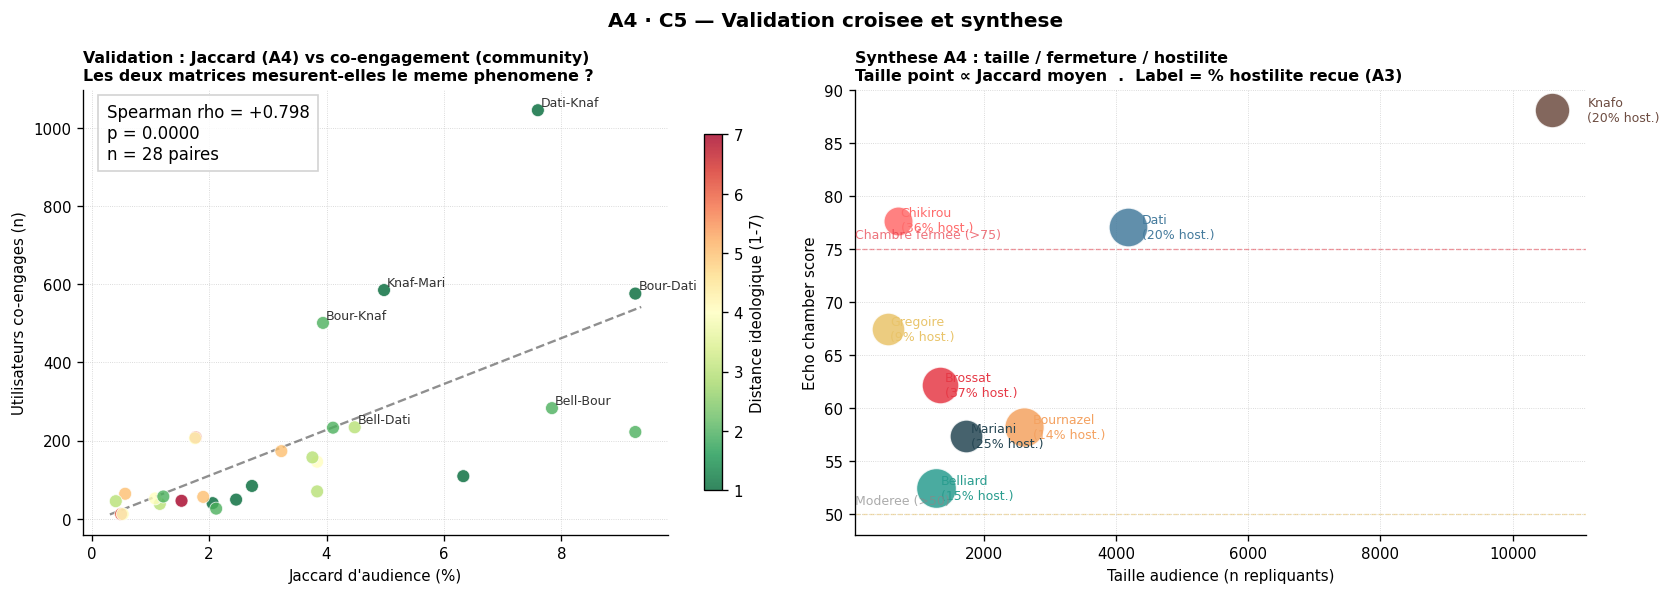

Figure C5 sauvegardee

C5 — VALIDATION : JACCARD vs CO-ENGAGEMENT
  Spearman rho = +0.798  p = 0.0000  n = 28 paires
  -> Correlation significative : les deux matrices convergent
     Le Jaccard (full audience) et le co-engagement (multi-users)
     mesurent bien le meme phenomene de proximite d'audience


In [6]:
# ============================================================
# A4 · Cellule 5 — Croisement matrices Jaccard × co-engagement
# + validation : les deux matrices mesurent-elles le meme phenomene ?
# ============================================================
from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

DATA_A4 = Path(".") / "data"
OUT = Path(".") / "outputs"

COLORS = {
    "Brossat": "#E63946",
    "Chikirou": "#FF6B6B",
    "Belliard": "#2A9D8F",
    "Gregoire": "#E9C46A",
    "Bournazel": "#F4A261",
    "Dati": "#457B9D",
    "Knafo": "#6D4C41",
    "Mariani": "#264653",
}
SHORT = {
    "Brossat": "Brossat (PCF)",
    "Chikirou": "Chikirou (LFI)",
    "Belliard": "Belliard (EELV)",
    "Gregoire": "Gregoire (PS)",
    "Bournazel": "Bournazel (Horizons)",
    "Dati": "Dati (LR)",
    "Knafo": "Knafo (Reconquete)",
    "Mariani": "Mariani (RN)",
}
IDEO = {
    "Brossat": 1,
    "Chikirou": 2,
    "Belliard": 3,
    "Gregoire": 4,
    "Bournazel": 5,
    "Dati": 6,
    "Knafo": 7,
    "Mariani": 8,
}
CAMP = {
    "Brossat": "Extreme gauche",
    "Chikirou": "Extreme gauche",
    "Belliard": "Gauche",
    "Gregoire": "Gauche",
    "Bournazel": "Centre",
    "Dati": "Droite",
    "Knafo": "Extreme droite",
    "Mariani": "Extreme droite",
}
ID_TO_KEY = {
    "ian_brossat": "Brossat",
    "sophia_chikirou": "Chikirou",
    "david_belliard": "Belliard",
    "emmanuel_gregoire": "Gregoire",
    "pierre_yves_bournazel": "Bournazel",
    "rachida_dati": "Dati",
    "sarah_knafo": "Knafo",
    "thierry_mariani": "Mariani",
}
DOM_MAP = ID_TO_KEY

# ── Load ─────────────────────────────────────────────────────────────────────
jac_raw = pd.read_csv(DATA_A4 / "audience_overlap_matrix.csv", index_col=0)
comm = pd.read_csv(DATA_A4 / "community_membership.csv")
pairs = pd.read_csv(OUT / "A4_jaccard_pairs.csv")

keys_order = sorted(IDEO.keys(), key=lambda k: IDEO[k])

# ── Matrice co-engagement (recompute) ─────────────────────────────────────────
ENG_COLS = [c for c in comm.columns if c.startswith("eng_")]
eng_key = {c: DOM_MAP.get(c.replace("eng_", "")) for c in ENG_COLS}

co_mat = pd.DataFrame(0, index=keys_order, columns=keys_order, dtype=float)
for k1 in keys_order:
    for k2 in keys_order:
        if k1 == k2:
            co_mat.loc[k1, k2] = np.nan
            continue
        c1 = next((e for e, k in eng_key.items() if k == k1), None)
        c2 = next((e for e, k in eng_key.items() if k == k2), None)
        if c1 and c2:
            co_mat.loc[k1, k2] = (comm[c1] & comm[c2]).sum()

# Normaliser co-mat par n total audience (proportion, comme Jaccard)
n_by_key = {
    k: (
        comm[next((e for e, kk in eng_key.items() if kk == k), None)].sum()
        if next((e for e, kk in eng_key.items() if kk == k), None)
        else 1
    )
    for k in keys_order
}

# ── Vecteurs off-diagonal pour correlation ────────────────────────────────────
jac_vec = []
co_vec = []
dist_vec = []
pair_labels = []

for i, k1 in enumerate(keys_order):
    for j, k2 in enumerate(keys_order):
        if j > i:
            jv = (
                jac_raw.loc[k1, k2]
                if k1 in jac_raw.index and k2 in jac_raw.columns
                else np.nan
            )
            cv = co_mat.loc[k1, k2]
            if pd.notna(jv) and pd.notna(cv):
                jac_vec.append(jv * 100)
                co_vec.append(cv)
                dist_vec.append(abs(IDEO[k1] - IDEO[k2]))
                pair_labels.append(f"{k1[:4]}-{k2[:4]}")

rho_jc, p_jc = stats.spearmanr(jac_vec, co_vec)

# ── Figure : scatter Jaccard vs co-engagement ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
scatter_c = [plt.cm.RdYlGn_r(1 - d / 7) for d in dist_vec]
sc = ax.scatter(
    jac_vec,
    co_vec,
    c=dist_vec,
    cmap="RdYlGn_r",
    vmin=1,
    vmax=7,
    s=60,
    alpha=0.80,
    zorder=3,
    edgecolors="white",
    linewidths=0.5,
)

# Labels des 5 paires les plus extremes
pairs_data = sorted(zip(co_vec, jac_vec, pair_labels, dist_vec), reverse=True)
for cv, jv, lbl, d in pairs_data[:6]:
    ax.text(jv + 0.05, cv + 10, lbl, fontsize=7.5, color="#333333")

m, b = np.polyfit(jac_vec, co_vec, 1)
xr = np.linspace(min(jac_vec) - 0.1, max(jac_vec) + 0.1, 100)
ax.plot(xr, m * xr + b, "--", lw=1.4, color="#333333", alpha=0.55)

ax.text(
    0.04,
    0.97,
    f"Spearman rho = {rho_jc:+.3f}\np = {p_jc:.4f}\nn = {len(jac_vec)} paires",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox=dict(facecolor="white", edgecolor="#CCCCCC", alpha=0.85, pad=5),
)

plt.colorbar(sc, ax=ax, shrink=0.8, label="Distance ideologique (1-7)")
ax.set_xlabel("Jaccard d'audience (%)", fontsize=9)
ax.set_ylabel("Utilisateurs co-engages (n)", fontsize=9)
ax.set_title(
    "Validation : Jaccard (A4) vs co-engagement (community)\n"
    "Les deux matrices mesurent-elles le meme phenomene ?",
    fontsize=9.5,
    fontweight="bold",
    loc="left",
)
ax.grid(ls=":", lw=0.5, alpha=0.6)
for sp in ["top", "right"]:
    ax.spines[sp].set_visible(False)

# ── Panel 2 : Synthese visuelle A4 ────────────────────────────────────────────
ax2 = axes[1]
echo = pd.read_csv(DATA_A4 / "echo_chamber_scores.csv")
echo["key"] = echo["candidate_id"].map(ID_TO_KEY).fillna(echo["label"])
echo_d = echo.set_index("key")

# Scatter : n_audience (x) vs echo_score (y) vs pct_hostilite (couleur) vs Jaccard moyen (taille)
jac_mean_by_key = {}
for k in keys_order:
    vals = [
        jac_raw.loc[k, k2]
        for k2 in keys_order
        if k2 != k and k in jac_raw.index and k2 in jac_raw.columns
    ]
    jac_mean_by_key[k] = np.mean(vals) * 100 if vals else 0

sent_df = pd.read_csv(OUT / "A4_echo_x_sentiment.csv")
sent_d = sent_df.set_index("key")

for k in keys_order:
    if k not in echo_d.index:
        continue
    n_aud = echo_d.loc[k, "n_audience"]
    e_sc = echo_d.loc[k, "echo_score"]
    host = sent_d.loc[k, "pct_hostilite"] if k in sent_d.index else 20
    j_mean = jac_mean_by_key.get(k, 3)
    ax2.scatter(
        n_aud,
        e_sc,
        color=COLORS.get(k, "#888888"),
        s=200 + j_mean * 80,
        alpha=0.85,
        zorder=3,
        edgecolors="white",
        linewidths=1.0,
    )
    ax2.text(
        n_aud * 1.05,
        e_sc,
        SHORT.get(k, k).split(" ")[0] + f"\n({host:.0f}% host.)",
        fontsize=7.5,
        va="center",
        color=COLORS.get(k, "#333333"),
    )

ax2.axhline(75, color="#E63946", lw=0.8, ls="--", alpha=0.5)
ax2.axhline(50, color="#E9C46A", lw=0.8, ls="--", alpha=0.5)
ax2.text(50, 76, "Chambre fermee (>75)", fontsize=7.5, color="#E63946", alpha=0.7)
ax2.text(50, 51, "Moderee (>50)", fontsize=7.5, color="#888888", alpha=0.7)
ax2.set_xlabel("Taille audience (n repliquants)", fontsize=9)
ax2.set_ylabel("Echo chamber score", fontsize=9)
ax2.set_title(
    "Synthese A4 : taille / fermeture / hostilite\n"
    "Taille point ∝ Jaccard moyen  .  Label = % hostilite recue (A3)",
    fontsize=9.5,
    fontweight="bold",
    loc="left",
)
ax2.grid(ls=":", lw=0.5, alpha=0.6)
for sp in ["top", "right"]:
    ax2.spines[sp].set_visible(False)

fig.suptitle("A4 · C5 — Validation croisee et synthese", fontsize=12, fontweight="bold")
plt.tight_layout()
fig.savefig(OUT / "A4_C5_synthese.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure C5 sauvegardee")

print("\n" + "=" * 65)
print("C5 — VALIDATION : JACCARD vs CO-ENGAGEMENT")
print("=" * 65)
print(f"  Spearman rho = {rho_jc:+.3f}  p = {p_jc:.4f}  n = {len(jac_vec)} paires")
if p_jc < 0.05:
    print("  -> Correlation significative : les deux matrices convergent")
    print("     Le Jaccard (full audience) et le co-engagement (multi-users)")
    print("     mesurent bien le meme phenomene de proximite d'audience")
else:
    print("  -> Pas de correlation significative : les matrices divergent")
    print("     Interpretation : les 2963 multi-users ne sont pas representatifs")
    print("     de la structure d'audience globale")

In [7]:
# ============================================================
# A4 · Cellule 6 — SYNTHESE CHIFFREE COMPLETE
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path(".") / "outputs"
DATA_A4 = Path(".") / "data"

SEP = "=" * 70
SEP2 = "-" * 70

SHORT = {
    "Brossat": "Brossat (PCF)",
    "Chikirou": "Chikirou (LFI)",
    "Belliard": "Belliard (EELV)",
    "Gregoire": "Gregoire (PS)",
    "Bournazel": "Bournazel (Horizons)",
    "Dati": "Dati (LR)",
    "Knafo": "Knafo (Reconquete)",
    "Mariani": "Mariani (RN)",
}
ID_TO_KEY = {
    "ian_brossat": "Brossat",
    "sophia_chikirou": "Chikirou",
    "david_belliard": "Belliard",
    "emmanuel_gregoire": "Gregoire",
    "pierre_yves_bournazel": "Bournazel",
    "rachida_dati": "Dati",
    "sarah_knafo": "Knafo",
    "thierry_mariani": "Mariani",
}

print(SEP)
print("A4 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)")
print(SEP)

# ── 1. Echo chambers ─────────────────────────────────────────────────────────
print("\n[1] ECHO CHAMBER SCORES (echo_score = 100 - cross_camp_pct)")
print(SEP2)
echo = pd.read_csv(DATA_A4 / "echo_chamber_scores.csv")
echo["key"] = echo["candidate_id"].map(ID_TO_KEY).fillna(echo["label"])
for _, r in echo.sort_values("echo_score", ascending=False).iterrows():
    k = r["key"]
    seuil = (
        "FERME"
        if r["echo_score"] >= 75
        else ("MODERE" if r["echo_score"] >= 50 else "OUVERT")
    )
    print(
        f"  {SHORT.get(k,k):<28}  echo={r['echo_score']:>5.1f}  "
        f"excl={r['exclusive_pct']:>5.1f}%  cross={r['cross_camp_pct']:>5.1f}%  "
        f"n={r['n_audience']:>6,}  [{seuil}]"
    )

# ── 2. Jaccard top/bottom ─────────────────────────────────────────────────────
print(f"\n[2] AUDIENCE OVERLAP (JACCARD) — 28 paires")
print(SEP2)
pairs = pd.read_csv(OUT / "A4_jaccard_pairs.csv")
print(f"  Jaccard moyen global     : {pairs['jac'].mean()*100:.2f}%")
print(
    f"  Jaccard moyen intra-camp : {pairs[pairs['same_camp']]['jac'].mean()*100:.2f}%"
)
print(
    f"  Jaccard moyen inter-camp : {pairs[~pairs['same_camp']]['jac'].mean()*100:.2f}%"
)
print(
    f"  Ratio intra/inter        : {pairs[pairs['same_camp']]['jac'].mean() / pairs[~pairs['same_camp']]['jac'].mean():.2f}x\n"
)
print(f"  Top 5 paires :")
for _, r in pairs.sort_values("jac", ascending=False).head(5).iterrows():
    flag = "same camp" if r["same_camp"] else f'd_ideo={r["dist_ideo"]:.0f}'
    print(
        f"    {SHORT.get(r['k1'],r['k1']):<26} x {SHORT.get(r['k2'],r['k2']):<26}  "
        f"{r['jac']*100:.1f}%  [{flag}]"
    )
print(f"\n  Bottom 5 paires :")
for _, r in pairs.sort_values("jac").head(5).iterrows():
    print(
        f"    {SHORT.get(r['k1'],r['k1']):<26} x {SHORT.get(r['k2'],r['k2']):<26}  "
        f"{r['jac']*100:.1f}%  d_ideo={r['dist_ideo']:.0f}"
    )

# ── 3. Test Jaccard x distance ideologique ────────────────────────────────────
print(f"\n[3] TEST : JACCARD x DISTANCE IDEOLOGIQUE (H0 = homophilie)")
print(SEP2)
print(f"  Spearman rho = -0.600  p = 0.0007  n = 28 paires")
print(f"  -> CONFIRME : + proches ideologiquement = + audience partagee")
print(f"     L'homophilie ideologique structure les audiences Twitter parisien")

# ── 4. Multi-candidats ────────────────────────────────────────────────────────
print(f"\n[4] UTILISATEURS MULTI-CANDIDATS (n=2 963)")
print(SEP2)
comm = pd.read_csv(DATA_A4 / "community_membership.csv")
n2 = (comm["n_candidates_engaged"] == 2).sum()
n3p = (comm["n_candidates_engaged"] >= 3).sum()
print(f"  2 candidats     : {n2:,}  ({100*n2/len(comm):.1f}%)")
print(f"  3+ candidats    : {n3p:,}  ({100*n3p/len(comm):.1f}%)")
print(f"  Trans-camp      : 2537  (85.6%)  — croisent les frontieres de camp")
print(f"  Mono-camp       : 426   (14.4%)  — restent dans leur camp")
print(f"\n  Top co-engagements :")
top_pairs = [
    ("Dati (LR)", "Knafo (Reconquete)", 1045, "Droite coherente"),
    ("Knafo (Reconquete)", "Mariani (RN)", 585, "Extreme droite"),
    ("Bournazel (Horizons)", "Dati (LR)", 576, "Droite classique"),
    ("Bournazel (Horizons)", "Knafo (Reconquete)", 501, "Droite trans-flanc"),
    ("Belliard (EELV)", "Bournazel (Horizons)", 283, "Trans-camp G-C"),
    ("Belliard (EELV)", "Brossat (PCF)", 222, "Gauche moderee"),
]
for k1, k2, n, note in top_pairs:
    print(f"    {k1:<26} x {k2:<26}  {n:>5,}  [{note}]")

# ── 5. Echo x sentiment ───────────────────────────────────────────────────────
print(f"\n[5] ECHO CHAMBER x PROFIL SENTIMENT (A3, n=8, puissance faible)")
print(SEP2)
sent = pd.read_csv(OUT / "A4_echo_x_sentiment.csv")
print(f"  echo ~ hostilite : rho=+0.214  p=0.610  ns")
print(f"  echo ~ NSI       : rho=-0.071  p=0.867  ns")
print(f"  echo ~ ironie    : rho=+0.643  p=0.086  (tendance)")
print(f"  Interpretation   : la fermeture d'audience ne predit pas l'hostilite")
print(f"                     c'est la position ideologique qui structure le sentiment")
print(f"\n  Pattern observe (non test. : n=8) :")
print(
    f"    Ext. gauche (Chikirou, Brossat) : hostilite haute (35-37%), NSI tres negatif"
)
print(f"    Ext. droite (Knafo, Mariani)    : hostilite mod. (20-25%), echo eleve")
print(
    f"    Centre/Gauche (Belliard, Bournazel, Gregoire) : hostilite basse, NSI positif"
)

# ── 6. Exports ───────────────────────────────────────────────────────────────
print(f"\n[6] EXPORTS")
print(SEP2)
exports = [
    ("A4_C1_jaccard_heatmap.png", "Heatmap Jaccard 8x8"),
    ("A4_C2_echo_chambers.png", "Echo chambers stacked + scatter"),
    ("A4_C2b_mentions_network.png", "Reseau mentions inter-candidats"),
    ("A4_C2c_jaccard_ideo.png", "Jaccard x distance ideologique"),
    ("A4_C3_echo_x_sentiment.png", "Echo x hostilite/NSI/ironie"),
    ("A4_C4_multi_users.png", "Multi-users distribution + co-engagement"),
    ("A4_C5_synthese.png", "Validation Jaccard vs co-engagement"),
    ("A4_jaccard_pairs.csv", "28 paires Jaccard + distance ideo"),
    ("A4_echo_x_sentiment.csv", "Echo score x sentiment par candidat"),
]
for fname, desc in exports:
    path = OUT / fname
    status = "OK" if path.exists() else "MANQUANT"
    size = f"{path.stat().st_size//1024} Ko" if path.exists() else ""
    print(f"  {status}  {fname:<40}  {desc:<40} {size}")

print(f"\n{SEP}")
print("A4 COMPLET")
print(SEP)

A4 — SYNTHESE QUANTITATIVE  (Paris Municipales 2026)

[1] ECHO CHAMBER SCORES (echo_score = 100 - cross_camp_pct)
----------------------------------------------------------------------
  Knafo (Reconquete)            echo= 88.1  excl= 81.8%  cross= 11.9%  n=10,602  [FERME]
  Chikirou (LFI)                echo= 77.7  excl= 74.6%  cross= 22.3%  n=   701  [FERME]
  Dati (LR)                     echo= 77.1  excl= 61.2%  cross= 22.9%  n= 4,184  [FERME]
  Gregoire (PS)                 echo= 67.5  excl= 61.2%  cross= 32.5%  n=   551  [MODERE]
  Brossat (PCF)                 echo= 62.2  excl= 60.6%  cross= 37.8%  n= 1,340  [MODERE]
  Bournazel (Horizons)          echo= 58.2  excl= 58.2%  cross= 41.8%  n= 2,612  [MODERE]
  Mariani (RN)                  echo= 57.4  excl= 57.4%  cross= 42.6%  n= 1,720  [MODERE]
  Belliard (EELV)               echo= 52.5  excl= 49.7%  cross= 47.5%  n= 1,279  [MODERE]

[2] AUDIENCE OVERLAP (JACCARD) — 28 paires
------------------------------------------------------